In [1]:
from multicam_recorder import MultiCameraRecorder
from video_synchronizer import VideoSynchronizer
import time
from datetime import datetime

In [2]:
# 1. Setup recorder
recorder = MultiCameraRecorder(
    camera_ids=[0, 1, 2],  # Your cameras
    fps=30
)

data_dir = '/Users/robertseymour/Documents/recordings/'


INFO:multicam_recorder:MultiCameraRecorder initialized with cameras: [0, 1, 2]


In [3]:
# 2. Connect to cameras (once)
recorder.connect_cameras()

INFO:multicam_recorder:Connecting to camera 0...
INFO:multicam_recorder:Camera 0 (Camera 0): 1280x720 @ 30fps
INFO:multicam_recorder:Connecting to camera 1...
INFO:multicam_recorder:Camera 1 (Camera 1): 1280x720 @ 30fps
INFO:multicam_recorder:Connecting to camera 2...
INFO:multicam_recorder:Camera 2 (Camera 2): 1280x720 @ 30fps
INFO:multicam_recorder:Connected to 3/3 cameras


{0: True, 1: True, 2: True}

In [4]:
recorder.preview_cameras(duration=5.0,target_fps=30)

INFO:multicam_recorder:Showing preview for 5.0s at ~30fps (press 'q' to quit)...
INFO:multicam_recorder:Preview resolution: 640x360 (50% of original)


In [5]:
# 3. Record Trial 1
# Get current timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H_%M_%S")

recorder.start_recording(data_dir+'recording_' + timestamp)
time.sleep(10)  # Record for 10 seconds
recorder.stop_recording()

INFO:multicam_recorder:Starting recording: /Users/robertseymour/Documents/recordings/recording_20260206_10_06_22
INFO:multicam_recorder:Camera 0 recording to /Users/robertseymour/Documents/recordings/recording_20260206_10_06_22/raw_videos/camera_0.avi
INFO:multicam_recorder:Camera 1 recording to /Users/robertseymour/Documents/recordings/recording_20260206_10_06_22/raw_videos/camera_1.avi
INFO:multicam_recorder:Camera 2 recording to /Users/robertseymour/Documents/recordings/recording_20260206_10_06_22/raw_videos/camera_2.avi
INFO:multicam_recorder:Recording started on 3 cameras


INFO:multicam_recorder:Stopping recording...
INFO:multicam_recorder:Camera 0 stopped recording: 300 frames
INFO:multicam_recorder:Camera 1 stopped recording: 302 frames
INFO:multicam_recorder:Camera 2 stopped recording: 306 frames
INFO:multicam_recorder:Recording stopped: /Users/robertseymour/Documents/recordings/recording_20260206_10_06_22


{0: (300,
  [1770372382.695148,
   1770372382.72732,
   1770372382.756247,
   1770372382.790238,
   1770372382.822978,
   1770372382.855296,
   1770372382.8895428,
   1770372382.9212759,
   1770372382.957185,
   1770372382.988246,
   1770372383.0208251,
   1770372383.054427,
   1770372383.087198,
   1770372383.119012,
   1770372383.153675,
   1770372383.186702,
   1770372383.218996,
   1770372383.252167,
   1770372383.283364,
   1770372383.315743,
   1770372383.350483,
   1770372383.3854961,
   1770372383.41804,
   1770372383.449871,
   1770372383.484274,
   1770372383.5167549,
   1770372383.5496562,
   1770372383.5831869,
   1770372383.61494,
   1770372383.6470258,
   1770372383.680979,
   1770372383.714012,
   1770372383.745804,
   1770372383.778692,
   1770372383.811522,
   1770372383.84602,
   1770372383.877434,
   1770372383.9110441,
   1770372383.944088,
   1770372383.977802,
   1770372384.011277,
   1770372384.044582,
   1770372384.0776992,
   1770372384.110293,
   1770372384.14

In [6]:
# 5. Disconnect
recorder.disconnect_cameras()

INFO:multicam_recorder:Disconnecting cameras...
INFO:multicam_recorder:Stopping camera 0...
INFO:multicam_recorder:Camera 0 stopped successfully
INFO:multicam_recorder:Stopping camera 1...
INFO:multicam_recorder:Camera 1 stopped successfully
INFO:multicam_recorder:Stopping camera 2...
INFO:multicam_recorder:Camera 2 stopped successfully
INFO:multicam_recorder:All cameras disconnected successfully


In [7]:
from sync_by_timestamps import synchronize_videos_to_ideal_fps
from plot_sync_results import plot_sync_results, plot_sync_summary_stats


In [8]:
# Synchronize all videos to camera 0
trial_dir = data_dir+'recording_' + timestamp

# Synchronize to ideal 30 FPS (or whatever you specify)
results = synchronize_videos_to_ideal_fps(
    trial_folder=trial_dir,
    target_fps=30.0,  # Your target FPS
    max_time_diff_ms=50.0
)


Timestamp-based Synchronization to Ideal 30.0 FPS Clock
Trial folder: /Users/robertseymour/Documents/recordings/recording_20260206_10_06_22
Raw videos:   /Users/robertseymour/Documents/recordings/recording_20260206_10_06_22/raw_videos
Output dir:   /Users/robertseymour/Documents/recordings/recording_20260206_10_06_22/synchronized_videos
Target FPS:   30.0

[1] Loading timestamps...
  Camera 2: 306 timestamps, range: [1770372382.733, 1770372392.913]s
  Camera 1: 302 timestamps, range: [1770372382.727, 1770372392.787]s
  Camera 0: 300 timestamps, range: [1770372382.695, 1770372392.690]s

[2] Finding global time range...
  Global start time: 1770372382.733s
  Global end time:   1770372392.690s
  Duration:          9.957s

[3] Creating ideal 30.0 FPS timing grid...
  Ideal frame count: 299
  Ideal duration:    9.933s

[4] Finding video files...
  Camera 0: camera_0.avi
  Camera 1: camera_1.avi
  Camera 2: camera_2.avi

[5] Getting video properties...
  Output FPS:        30.00
  Output re


📊 Plots saved to: /Users/robertseymour/Documents/recordings/recording_20260206_10_06_22/synchronization_plots/sync_analysis.png
📊 PDF saved to: /Users/robertseymour/Documents/recordings/recording_20260206_10_06_22/synchronization_plots/sync_analysis.pdf


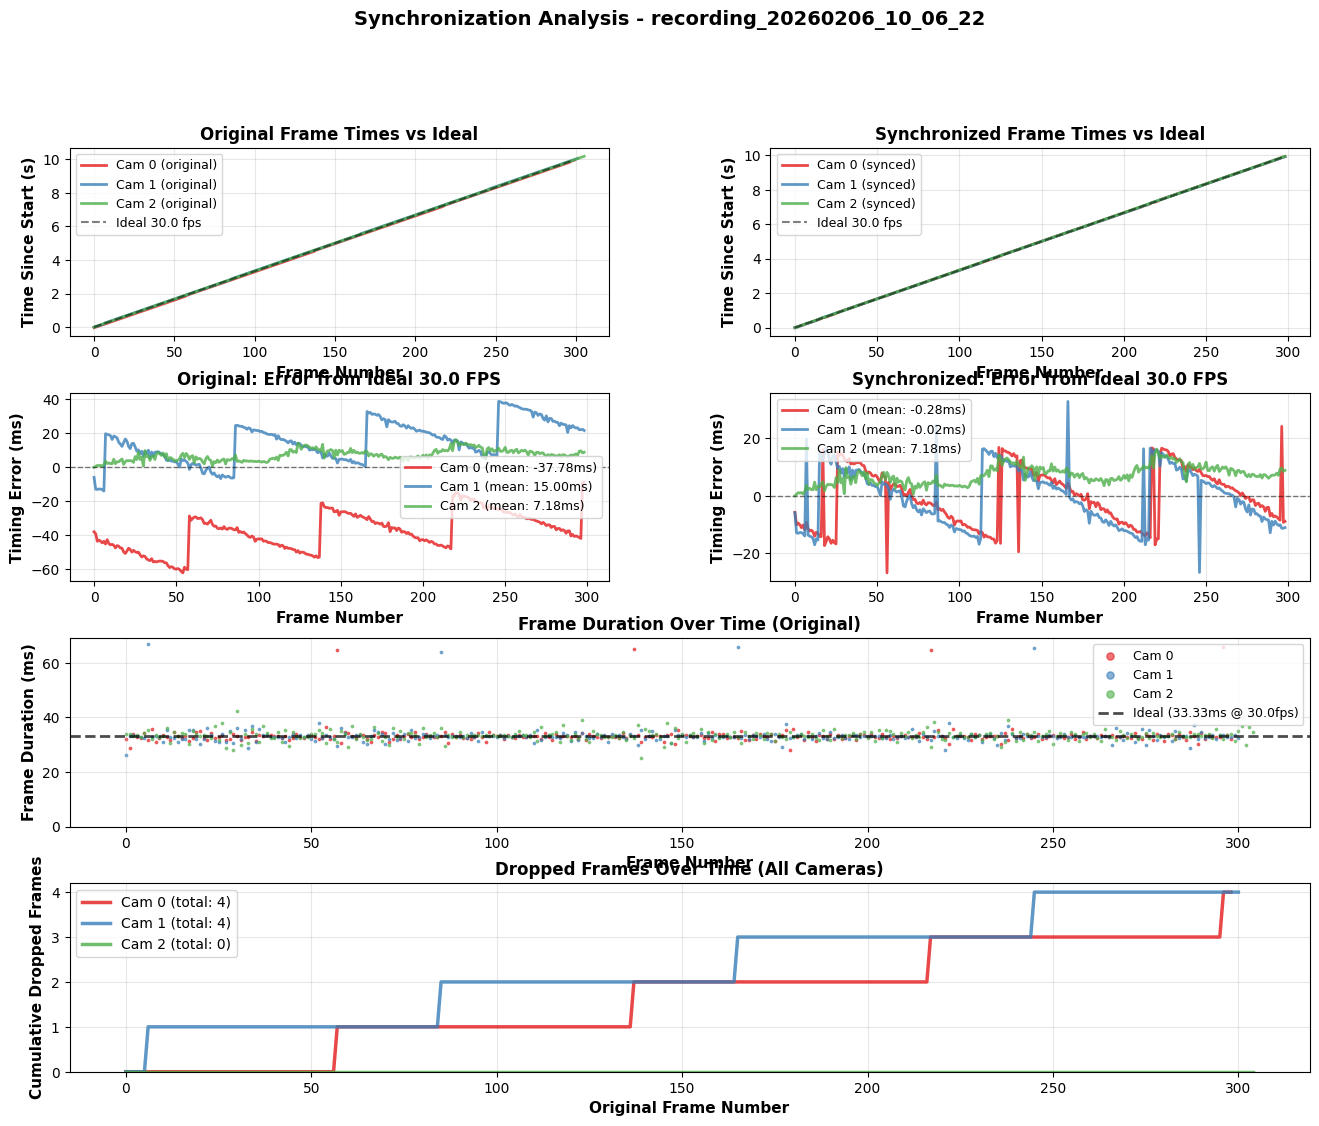

📊 Summary plots saved to: /Users/robertseymour/Documents/recordings/recording_20260206_10_06_22/synchronization_plots/sync_summary.png


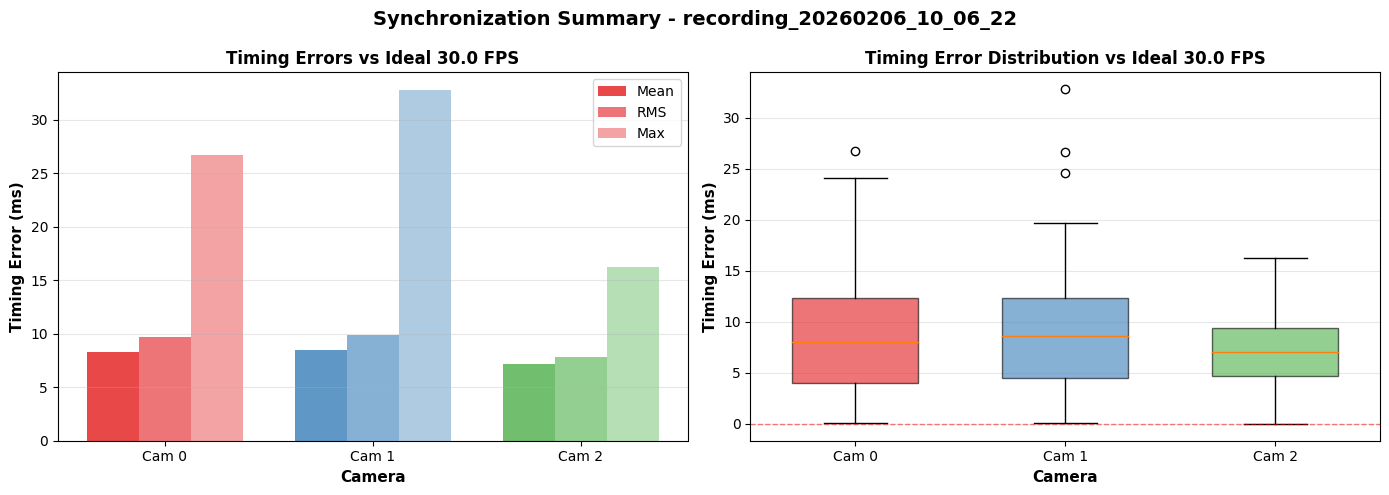

In [9]:
# Create plots
figs = plot_sync_results(
    results=results,
    trial_folder=trial_dir,
    save_plots=True,
    show_plots=True
)

# Summary stats
fig_summary = plot_sync_summary_stats(
    results=results,
    trial_folder=trial_dir,
    save_plots=True
)

In [10]:
from pathlib import Path
import cv2
import numpy as np

def save_synced_videos_side_by_side(
    trial_folder,
    synced_subdir="synchronized_videos",
    out_name="synchronized_side_by_side.avi",
    max_width=1920,
):
    """
    Combine synchronized videos into a single side-by-side MP4 for offline review.

    Assumes:
      - Videos are already synchronized
      - All have identical frame counts
      - Filenames: camera_<id>_synchronized.mp4
    """
    trial_folder = Path(trial_folder)
    synced_dir = trial_folder / synced_subdir
    out_path = trial_folder / out_name

    videos = sorted(synced_dir.glob("camera_*_synchronized.avi"))
    if not videos:
        raise FileNotFoundError(f"No synchronized videos found in {synced_dir}")

    caps = []
    cam_ids = []

    for v in videos:
        cap = cv2.VideoCapture(str(v))
        if not cap.isOpened():
            raise RuntimeError(f"Could not open {v}")
        caps.append(cap)
        cam_ids.append(int(v.stem.split("_")[1]))

    # --- checks ---
    frame_counts = [int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) for cap in caps]
    if len(set(frame_counts)) != 1:
        raise ValueError(f"Frame count mismatch: {dict(zip(cam_ids, frame_counts))}")

    fps = caps[0].get(cv2.CAP_PROP_FPS)
    n_frames = frame_counts[0]

    # Read one frame to determine sizes
    ok, first_frame = caps[0].read()
    if not ok:
        raise RuntimeError("Failed to read first frame")
    h, w = first_frame.shape[:2]

    # Reset all captures to frame 0
    for cap in caps:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    tiled_w = w * len(caps)
    tiled_h = h

    # Optional downscale to fit screen width
    scale = 1.0
    if tiled_w > max_width:
        scale = max_width / tiled_w
        tiled_w = int(tiled_w * scale)
        tiled_h = int(tiled_h * scale)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(
        str(out_path),
        fourcc,
        fps,
        (tiled_w, tiled_h),
    )
    if not writer.isOpened():
        raise RuntimeError(f"Could not open VideoWriter for {out_path}")

    print(f"Writing side-by-side video:")
    print(f"  cameras: {cam_ids}")
    print(f"  frames:  {n_frames}")
    print(f"  fps:     {fps:.2f}")
    print(f"  output:  {out_path}")

    # --- write ---
    for i in range(n_frames):
        frames = []
        for cam_id, cap in zip(cam_ids, caps):
            ok, frame = cap.read()
            if not ok:
                raise RuntimeError(f"Failed reading frame {i} from camera {cam_id}")

            # overlay text
            cv2.putText(
                frame,
                f"Cam {cam_id} | frame {i}",
                (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.0,
                (0, 255, 0),
                2,
                cv2.LINE_AA,
            )
            frames.append(frame)

        combined = np.hstack(frames)

        if scale != 1.0:
            combined = cv2.resize(
                combined,
                (tiled_w, tiled_h),
                interpolation=cv2.INTER_AREA,
            )

        writer.write(combined)

    # cleanup
    writer.release()
    for cap in caps:
        cap.release()

    print("Done ✅")
    return out_path





In [11]:
# ---- usage ----
out_video = save_synced_videos_side_by_side(trial_dir)
out_video

Writing side-by-side video:
  cameras: [0, 1, 2]
  frames:  299
  fps:     30.00
  output:  /Users/robertseymour/Documents/recordings/recording_20260206_10_06_22/synchronized_side_by_side.avi
Done ✅


PosixPath('/Users/robertseymour/Documents/recordings/recording_20260206_10_06_22/synchronized_side_by_side.avi')